# 피처 엔지니어링

1. 피처란 무엇인가?
2. 스케일링 - 크기맞추기
3. 인코딩 - 문자를 숫자로
4. 파생변수 만들기
5. 데이터 누수

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from _style import setup
from _ml import build_dataset, FEATURES, SEED, time_split, load_merged

setup()
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 20)

print("준비완료")

[폰트] Malgun Gothic / unicode_minus=False
준비완료


---
## 1. 피처란 무엇인가

**모델에 넣는 입력 변수 하나하나**를 피처(특성)라고 한다.
X를 이루는 열들.

```
X(피처)                           y(정답)
-------------------------------------
수익률 거래량 이평선 변동성      ->  상승/하락
```

**피처 엔지니어링**은 원본 데이터를 모델이 쓸 수 있는 형태로 바꾸고,
**더 나은 피처를 만들어내는** 작업이다.

In [2]:
df = build_dataset()

# 우리가 사용할 피처 7개
설명 = {
    "ret_1d" : "전일 수익률",        
    "ret_5d" : "5일 수익률",       
    "ma5_ratio" : "종가/5일 이동평균",    
    "ma20_ratio": "종가/20일 이동평균",   
    "vol20" : "20일 변동성",        
    "volume_ratio": "거래량 / 20일 평균 거래량",  
    "range_pct" : "(고가 - 저가) / 저가",     
}

print(f"{'피처':<16}{'의미'}")
print("="*60)
for f in FEATURES:
    print(f"{f:<16}{설명[f]}")


피처              의미
ret_1d          전일 수익률
ret_5d          5일 수익률
ma5_ratio       종가/5일 이동평균
ma20_ratio      종가/20일 이동평균
vol20           20일 변동성
volume_ratio    거래량 / 20일 평균 거래량
range_pct       (고가 - 저가) / 저가


> 이미 우리가 만든 데이터에는 파생변수들이 존재한다.
> 데이터 전처리과정에서 지표라고 불렀던 것들이 모델이 넣는 순가 피처가 된다.

### 피처는 모델보다 중요하다.

같은 데이터로 알고리즘만 바꿔서 얻는 성능향상은 대개 몇퍼센트정도가 최선이다.
그런데 **좋은 피처 하나를 추가하면** 성능이 크게 뛸 수 있다.

In [4]:
# 피처를 늘려가면서 성능이 어떻게 변하는지 보자
from sklearn.ensemble import RandomForestClassifier

train, test, cutoff = time_split(df)

tr = train.sample(15000, random_state=SEED)
te = test.sample(4000, random_state=SEED)

조합 = {
    "1. 수익률만": ["ret_1d"],
    "2 + 이동평균" : ["ret_1d", "ma5_ratio", "ma20_ratio"],
    "3 + 변동성, 거래량": FEATURES,
}

for name, feats in 조합.items():
    m = RandomForestClassifier(n_estimators=50, max_depth=6,
                               random_state=SEED, n_jobs=-1)
    m.fit(tr[feats], tr["target_up"])
    print(f"{name:<20} 피처 {len(feats)}개    정확도 {m.score(te[feats], te['target_up']):.4f}")
    


1. 수익률만              피처 1개    정확도 0.4858
2 + 이동평균             피처 3개    정확도 0.4853
3 + 변동성, 거래량         피처 7개    정확도 0.4905


> **주가 예측은 원래 어렵습니다.**
>
> 피처를 늘려도 정확도가 크게 오르지 않는다. 50%근적이면 정상이다.
> **금융 시계열은 대부분 예측 불가능한 잡음**이기 떄문이다.

---
## 2. 스케일링 - 크기를 맞춘다.

```
종가    52,000
등락률     2.7
거래량  1,240,000
```

세 변수의 **숫자 범위가 전혀 다르다**
거기를 계산하는 알고리즘은 거래량 하나에 끌려더니게 된다. 등락률은 사실상 무시될 확률이 높다.

In [ ]:
# 우리 피처들의 범위
print(df[FEATURES].agg(["mean", "std", "min", "max"]).T.round(4).to_string())

                mean     std     min      max
ret_1d       -0.0003  0.0263 -0.2573   0.2755
ret_5d       -0.0012  0.0607 -0.3367   0.4257
ma5_ratio     0.9989  0.0295  0.7617   1.2395
ma20_ratio    0.9955  0.0679  0.6374   1.4317
vol20         0.0243  0.0100  0.0079   0.0677
volume_ratio  1.0023  0.9574  0.0915  15.6764
range_pct     0.0436  0.0204  0.0010   0.3370


In [8]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

X_train, X_test = train[FEATURES], test[FEATURES]

scaler = StandardScaler()

# fit_transform은 학습 데이터에만 
# fit + transform : fit(평균과 표준편차를 계산) + transform(계산된 기준으로 변환)
X_train_scaled = scaler.fit_transform(X_train)

# 테스트 데이터는 transform만
# 학습에서 구한 평균, 표준편차를 그대로 적용.
X_test_scaled = scaler.transform(X_test)

print(f"{'':<16}{'평균':>12}{'표준편차':>12}")
print("-"*60)
print(f"{'학습(변환 후)':<16}{X_train_scaled.mean():>12.6f}{X_train_scaled.std():>12.4f}")
print(f"{'테스트(변환 후)':<16}{X_test_scaled.mean():>12.6f}{X_test_scaled.std():>12.4f}")

                          평균        표준편차
------------------------------------------------------------
학습(변환 후)           -0.000000      1.0000
테스트(변환 후)           0.009261      0.9755


> **테스트 평균이 정확하게 0이 아닌 것이 정상이다**

학습 데이터의 평균,표준편차로 변환했기 때문에. 만약 테스트에서 평균0, 표준편차1이 나오면, 테스트 정보로 학습한 것.

In [12]:
# StandardScaler, MinMaxScaler

mm = MinMaxScaler().fit(X_train)
mm_train = mm.transform(X_train)

print(f"{'':<20}{'StandardScaler':<22}{'MinMaxScaler'}")
print("-"*60)
print(f"{'(변환 후)':<19}{'평균 0, 표준편차 1':<21}{'0~1'}")
print(f"{'이상치 영향':<19}{'상대적으로 덜함':<21}{'크게받음'}")
print("-"*60)
print(f"학습데이터 범위")
print(f"{X_train_scaled.min():.2f} ~ {X_train_scaled.max():.2f}")
print(f"{mm_train.min():.2f} ~ {mm_train.max():.2f}")

print("-"*60)
mm_test = mm.transform(X_test)
print(f"테스트데이터 범위")
print(f"{X_test_scaled.min():.2f} ~ {X_test_scaled.max():.2f}")
print(f"{mm_test.min():.2f} ~ {mm_test.max():.2f}")

                    StandardScaler        MinMaxScaler
------------------------------------------------------------
(변환 후)             평균 0, 표준편차 1         0~1
이상치 영향             상대적으로 덜함             크게받음
------------------------------------------------------------
학습데이터 범위
-9.76 ~ 15.21
0.00 ~ 1.00
------------------------------------------------------------
테스트데이터 범위
-7.73 ~ 15.39
-0.00 ~ 1.01


> **MinMaxScalerd에서도 테스트에서 0~1범위를 벗어날 수 있다.**

학습 데이터의 최솟값,최댓값으로 기준을 잡았는데, 테스트에 더 크거나 작은 값이 있을 수 있기때문에.

**트리계열은 스케일링이 필요가 없다**
"거래량이 ~~보다 큰가?처럼 기준값으로 나누는 방식이라 단위가 달라도 결과는 같다.

---
## 3. 인코딩 - 문자를 숫자로

모델은 숫자만 받는다. "ㅇㅇ전자"같은 문자열은 변환을 해야한다.

||LabelEncoder|One-Hot Encoding|
|---|---|---|
|결과|전기전자 -> 0, 금융 -> 1|범주마다 열 하나씩(0/1)|
|열 개수|1개|범주 수만큼|
|언제|순서가 있을 때|순서가 없을 때|

In [13]:
from sklearn.preprocessing import LabelEncoder

sample = pd.Series(["전기전자", "금융", "화학", "금융", "바이오"])

le = LabelEncoder()
encoded = le.fit_transform(sample)

print(f"원본 : {sample.tolist()}")
print(f"Label : {encoded.tolist()}")

원본 : ['전기전자', '금융', '화학', '금융', '바이오']
Label : [2, 0, 3, 0, 1]


**순서가 없는 범주에 LabelEncoder를 쓰면 안된다**

모델은 이 숫자를 크기로 이해할 수 있다. 화학=3, 금융=0이면 화학이 금융보다 매우크다라고 읽는다.

존재하지 않는 순서를 만들어 낼 수 있다.

초급 < 중급 < 고급 처럼 실제로 순서가 있으면 LabelEncoder를 사용하면 된다.

In [14]:
# One-Hot은 범주마다 열을 하나씩 만든다
onehot = pd.get_dummies(sample, prefix="sector").astype(int)

print(f"One-Hot 결과")
print(onehot.to_string(index=False))

One-Hot 결과
 sector_금융  sector_바이오  sector_전기전자  sector_화학
         0           0            1          0
         1           0            0          0
         0           0            0          1
         1           0            0          0
         0           1            0          0


In [18]:
full = load_merged()

n_sector = full["sector"].nunique()
n_code = full["code"].nunique()

#one-hot인코딩시 각각 범주 수 만큼 열이 생긴다
print(f"sector의 범주 수  : {n_sector}개")
print(f"code의 범주 수  : {n_code}개")

sample_df = full[["code", "sector", "close"]].head(10000)
encoded_df = pd.get_dummies(sample_df, columns=["sector"]).astype({"close": int})

print(f" 원본 열 수 : {sample_df.shape[1]}")
print(f" one-hot 후 : {encoded_df.shape[1]}")
print(sample_df)
print(encoded_df)


sector의 범주 수  : 10개
code의 범주 수  : 120개
 원본 열 수 : 3
 one-hot 후 : 9
       code sector  close
0     G0001   전기전자  24015
1     G0001   전기전자  24400
2     G0001   전기전자  24295
3     G0001   전기전자  23974
4     G0001   전기전자  23784
...     ...    ...    ...
9995  G0014    에너지   4792
9996  G0014    에너지   4766
9997  G0014    에너지   4694
9998  G0014    에너지   4512
9999  G0014    에너지   4459

[10000 rows x 3 columns]
       code  close  sector_IT서비스  sector_금융  sector_바이오  sector_에너지  sector_유통  sector_전기전자  sector_화학
0     G0001  24015         False      False       False       False      False         True      False
1     G0001  24400         False      False       False       False      False         True      False
2     G0001  24295         False      False       False       False      False         True      False
3     G0001  23974         False      False       False       False      False         True      False
4     G0001  23784         False      False       False       False      False   

**범주가 너무 많으면 One-Hot이 위험하다**

종목코드 120개를 One-Hot하면 열이 120개 늘어난다. 데이터는 넓어지는데 각 열은 거의 0이다. 낭비, 오히려 학습에 방해

이럴 때는 상위 몇개를 남기고 나머지는 기타로 묶는다.

In [20]:
top_n = 5
top_codes = full['code'].value_counts().head(top_n).index

grouped = full['code'].where(full['code'].isin(top_codes), "기타")

print(f"원래 범주 수 : {full['code'].nunique()}")
print(f"묶은 후 : {grouped.nunique()}")

원래 범주 수 : 120
묶은 후 : 6


> **테스트의 범주가 학습범주와 다를 때**
> 
> 학습 데이터에 없던 값이 테스트에 나타나면 열 구성이 달라져서 에러가 발생한다.

In [22]:
from sklearn.preprocessing import OneHotEncoder

학습_범주 = pd.DataFrame({"sector": ["금융", "화학", "금융"]})
테스트_범주 = pd.DataFrame({"sector": ["금융", "바이오"]})

enc = OneHotEncoder(sparse_output=False)
enc.fit(학습_범주)

try:
    enc.transform(테스트_범주)
except ValueError as e:
    print(f"기본 설정 -> ValueError")

#OneHotEncoder의 handle_unknown="ignore" - 모르는 값은 전부 0으로
enc2 = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
enc2.fit(학습_범주)
result = enc2.transform(테스트_범주)

print(f"열이름 : {enc2.get_feature_names_out().tolist()}")
print(f"결과 : \n{result}")

기본 설정 -> ValueError
열이름 : ['sector_금융', 'sector_화학']
결과 : 
[[1. 0.]
 [0. 0.]]


---
## 4. 파생변수 만들기

원본 열을 조합해 **더 의미 있는 변수**를 만든다. 여기가 도메인지식이 들어가는 공간 

|원본|파생변수|의미|
|---|---|---|
|종가|n일 이동평균비율|평소보다 가격이 높은가, 낮은가|
|종가|전일대비수익률|절대가격보다 변화크기가 중요|
|거래량|20일 평균 대비 배수|**거래량이 터졌는가?**|

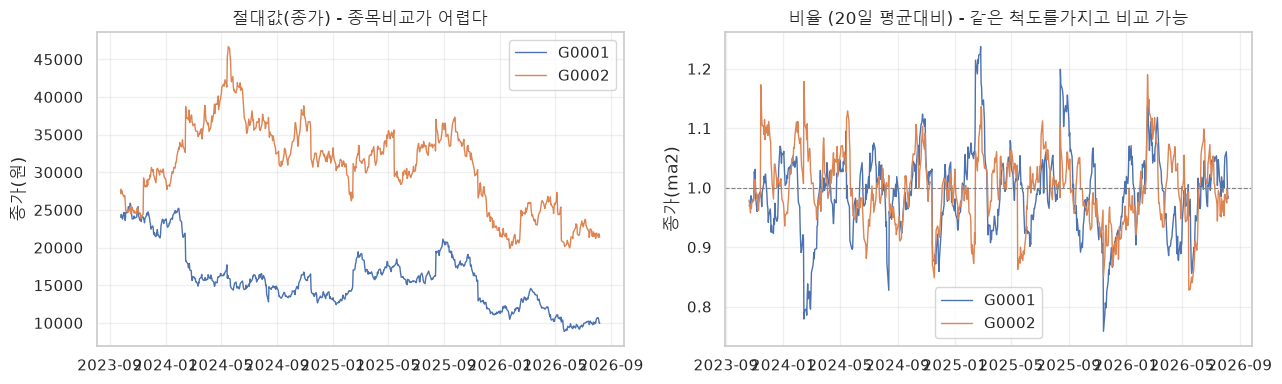

In [24]:
# 절대값과 비율이 어떻게 다른지 보자.

두종목 = full[full["code"].isin(["G0001", "G0002"])].copy()
두종목["ma20"] = 두종목.groupby("code")["close"].transform(lambda s: s.rolling(20).mean())
두종목["ma20_ratio"] = 두종목["close"] / 두종목["ma20"]

fig, axes = plt.subplots(1,2,figsize=(13,4))

for code, g in 두종목.groupby("code"):
    axes[0].plot(g["date"], g["close"], label=code, lw=1)
    axes[1].plot(g["date"], g["ma20_ratio"], label=code, lw=1)

axes[0].set_title("절대값(종가) - 종목비교가 어렵다")
axes[0].set_ylabel("종가(원)")
axes[1].set_title("비율 (20일 평균대비) - 같은 척도를가지고 비교 가능")
axes[1].axhline(1.0, color="gray", ls="--", lw=0.8)
axes[1].set_ylabel("종가(ma2)")

for ax in axes:
    ax.legend()
    ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

**절대값보다 비율이 대체로 낫다**

왼쪽 그림에서 두 종목은 가격대가 달라서 나란히 놓고 비교할 수 없다. 오른쪽은 달 다 1.0근처에서 움직인다.

### 도메인지식이 필요하다.

어떤 파생변수가 유효한지는 그 분야를 알아야 판단한 수 있다.

---
## 5. 데이터 누스

데이터 누수는 학습 시점에 알 수 없는 정보가 피처에 섞여 들어가는 것이다.

### 증상

```
검증 정확도 97%
실제 운영 54%
```

**성능이 지나치게 좋으면 기뻐할 것이 아니라 의심을 해봐야한다**

### 유형 세 가지

|유형|예|
|---|---|
|미래정보|오늘 종가로 오늘 피처를 만듬|
|정답누출|정답에서 파생된 변수를 피처에 넣음|
|전처리 누수|전체 데이터로 스케일링한 뒤 분할|

### 문제 설정을 다시 해보자.

> **"오늘 장이 끝나기 전에, 오늘 오를지 예측한다"**

이때 **오늘 종가는 아직 알 수 없다.** 그래서 피처는 어제까지의 정보여야한다.

```
오늘의 피처 = 오늘 종가 기준 이동평균
-> 오늘 종가는 끝나야 알 수 있기때문에 불가하다.

오늘의 피처 = 어제까지의 이동평균 (shift(1))
```

In [27]:
# 피처를 만드는 코드 부분 확인


#    if shift_features:
#         # 한 칸 밀어 '어제까지의 정보' 로 만든다. 반드시 종목별로.
#         for col in FEATURES:
#             df[col] = df.groupby("code")[col].shift(1)

# shift_features를 false로 두면 위에 코드가 빠진다.

정상 = build_dataset(shift_features=True)
누수 = build_dataset(shift_features=False)

cols = ["date", "close", "ret_1d", "target_ret", "target_up"]

def display_data(data):
    v = data[data["code"] == "G0001"][cols].head(4).reset_index(drop=True)
    v["date"] = v["date"].dt.date
    num = ["ret_1d", "target_ret"]
    v[num] = v[num].round(5)
    return v.to_string(index=False)

print("1. shift 적용(정상)")
print(display_data(정상))
print()
print("2. shift 미적용(누수)")
print(display_data(누수))



1. shift 적용(정상)
      date  close   ret_1d  target_ret  target_up
2023-10-24  24193  0.00092     0.01557          1
2023-10-25  23984  0.01557    -0.00864          0
2023-10-26  23913 -0.00864    -0.00296          0
2023-10-27  23977 -0.00296     0.00268          1

2. shift 미적용(누수)
      date  close   ret_1d  target_ret  target_up
2023-10-23  23822  0.00092     0.00092          1
2023-10-24  24193  0.01557     0.01557          1
2023-10-25  23984 -0.00864    -0.00864          0
2023-10-26  23913 -0.00296    -0.00296          0


**누수데이터를 확인하면**

ret_1d와 target_ret의 값이 완전히 동일.

ret_1d(오늘 수익률)와 target_ret(오늘의 수익률)이 같은 계산이기 때문이다. 즉 정답을 피처로 준거랑 동일하다.

In [28]:
# 두 버전으로 각각 학습해 성능을 비교
from sklearn.metrics import accuracy_score, roc_auc_score

결과 = []

for data, label in [(정상, "정상(shift적용)"), (누수, "누수(shift미적용)")]:
    tr_, te_, _ = time_split(data)
    tr_ = tr_.sample(15000, random_state=SEED)
    te_ = te_.sample(4000, random_state=SEED)

    m = RandomForestClassifier(n_estimators=50, max_depth=8,
                               random_state=SEED, n_jobs=-1)
    m.fit(tr_[FEATURES], tr_["target_up"])

    pred = m.predict(te_[FEATURES])
    proba = m.predict_proba(te_[FEATURES])[:,1]

    결과.append({
        "구분" : label,
        "정확도" : accuracy_score(te_["target_up"], pred),
        "AUC" : roc_auc_score(te_["target_up"], proba),
    })

print(pd.DataFrame(결과).round(4).to_string(index=False))

          구분    정확도    AUC
 정상(shift적용) 0.4992 0.4943
누수(shift미적용) 0.9992 0.9997


**정확도가 99%이상 나올 수 있다**

shift(1) 한 줄 빼먹어서.... 그리고 실제로는 사용이 불가하다. 운영에서 사용이 불가하다(오늘의 종가를 미리 입력으로 줄 수 없다.)

**누수를 의심해야하는 경우**

> - 성능이 기대보다 과하게 좋다.
> - 특정 피처 하나의 중요도가 앞도적으로 높다.
> - 학습과 테스트 성능차이가 거의 없다.

누수시에 피처를 전부 시각화해보면 특정피처와 정답이 동일하게 움직일 수 있다.
-> 특정피처의 중요도가 압도적인 경우이다. -> 누수

---
# 6.전처리 순서와 Pipeline

> 1. 결측, 이상치처리
> 2. 파생변수 생성
> 3. 학습 / 테스트 분할
> 4. 스케일링, 인코딩 fit   학습데이터로만
> 5. 양쪽에 transform

---
# 정리

|개념|내용|
|---|---|
|피처|지표와같이 모델에 영향을 주는 변수|
|스케일링|데이터 표준화(fit_transform은 학습데이터에만)|
|인코딩|문자->숫자(순서없는 범주에는 LabelEncoder 금지)|
|파생변수|기존데이터로부터 만든 변수(절대값보다는 비율)|
|데이터 누수|성능이 너무 좋으면 의심해라|
|Pipeline|누수를 구조적으로 차단|